In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/hieubui/Desktop/my_fruit_fly/data/720575940627190556,720575940632427603,720575940632504874,720575940634612194,720575940629382150.csv")
df.head()

,root_id,label,name,nt_type,flow,super_class,class,sub_class,cell_type,hemilineage,nerve,connectivity_tag,side,input_synapses,output_synapses
0,720575940627190556,['Lobula Plate intrinsic neuron 1-2; LPi1-2'],LOP.8,GABA,intrinsic,optic,optic_lobe_intrinsic,lobula_plate_intrinsic,['LPi14'],NaN,NaN,['rich_club'; 'reciprocal'; 'feedforward_loop_...,right,33267,20824
1,720575940632427603,['H2 (part of Reiser Lab LPTC catalog)'; 'lobu...,LOP.IPS.1,ACH,intrinsic,visual_projection,NaN,NaN,['H2'],NaN,NaN,['rich_club'; 'integrator'; 'reciprocal'; 'fee...,right,22589,5242
2,720575940632504874,['Lobula Plate intrinsic neuron 1-2; LPi1-2'],LOP.7,GABA,intrinsic,optic,optic_lobe_intrinsic,lobula_plate_intrinsic,['LPi14'],NaN,NaN,['rich_club'; 'reciprocal'; 'feedforward_loop_...,right,33185,20486
3,720575940634612194,['Lobula Plate intrinsic neuron 2-1f; LPi2-1f'...,LOP.3,GABA,intrinsic,optic,optic_lobe_intrinsic,lobula_plate_intrinsic,['LPi15'],NaN,NaN,['rich_club'; 'reciprocal'; 'feedforward_loop_...,right,60169,39297
4,720575940629382150,['Lobula Plate intrinsic neuron 2b; LPi2b'; '(...,LOP.5,GABA,intrinsic,optic,optic_lobe_intrinsic,lobula_plate_intrinsic,['LPi12'],NaN,NaN,['rich_club'; 'reciprocal'; 'feedforward_loop_...,right,16851,24542


In [4]:
df[[
    "root_id",
    "cell_type",
    "nt_type",
    "input_synapses",
    "output_synapses"
]]

,root_id,cell_type,nt_type,input_synapses,output_synapses
0,720575940627190556,['LPi14'],GABA,33267,20824
1,720575940632427603,['H2'],ACH,22589,5242
2,720575940632504874,['LPi14'],GABA,33185,20486
3,720575940634612194,['LPi15'],GABA,60169,39297
4,720575940629382150,['LPi12'],GABA,16851,24542


In [31]:
df2 = pd.read_csv("/Users/hieubui/Desktop/my_fruit_fly/data/connections.csv")
df2.head()

,From,To,Neuropil,Synapses,Neuro Transmitter
0,720575940629382150,720575940634612194,LOP_R,1737,GABA
1,720575940627190556,720575940632427603,LOP_R,1329,GABA
2,720575940632504874,720575940632427603,LOP_R,1213,GABA
3,720575940627190556,720575940634612194,UNASGD,2,GABA
4,720575940627190556,720575940634612194,LOP_R,1065,GABA


In [32]:
print("Connections Table's Shape:", df2.shape)
print("Connections Table's Columns:", df2.columns)

Connections Table's Shape: (23, 5)
Connections Table's Columns: Index(['From', 'To', 'Neuropil', 'Synapses', 'Neuro Transmitter'], dtype='object')


In [33]:
# Combine duplicate connections
connections = (                      # con = connections
    df2.groupby(
        ["From", "To", "Neuro Transmitter"], as_index=False)["Synapses"].sum()
)

In [34]:
len(connections)

20

Now we have 5 nodes and 20 connections

In [35]:
G = nx.DiGraph()

In [ ]:
# Replace the id num to cell label
name_map = {
    720575940627190556: "LPi14_A",
    720575940632427603: "H2",
    720575940632504874: "LPi14_B",
    720575940634612194: "LPi15",
    720575940629382150: "LPi12"
}

connections["From_name"] = connections["From"].map(name_map)
connections["To_name"] = connections["To"].map(name_map)

connections[
    ["From_name", "To_name", "Synapses", "Neuro Transmitter"]
]

,From_name,To_name,Synapses,Neuro Transmitter
0,LPi14_A,LPi12,32,GABA
1,LPi14_A,H2,1329,GABA
2,LPi14_A,LPi14_B,20,GABA
3,LPi14_A,LPi15,1067,GABA
4,LPi12,LPi14_A,14,GABA
5,LPi12,H2,65,GABA
6,LPi12,LPi14_B,27,GABA
7,LPi12,LPi15,1737,GABA
8,H2,LPi14_A,14,ACH
9,H2,LPi12,27,ACH


In [37]:
for _, row in connections.iterrows():

    G.add_edge(
        str(row["From_name"]),
        str(row["To_name"]),
        weight=row["Synapses"],
        neurotransmitter=row["Neuro Transmitter"]
    )

print("Neurons:", G.number_of_nodes())
print("Connections", G.number_of_edges())

Neurons: 5
Connections 20


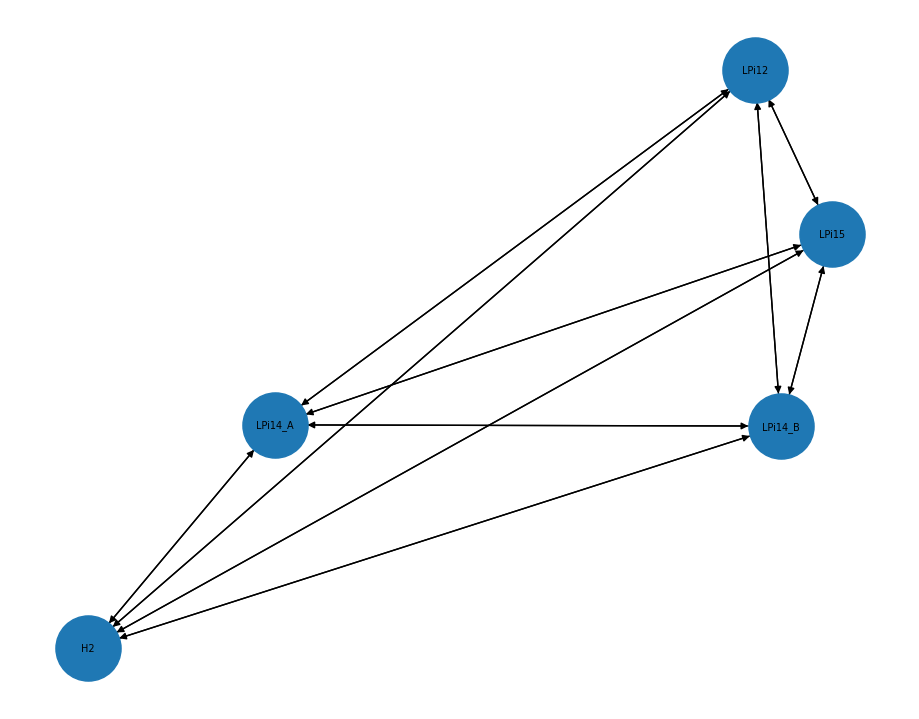

In [38]:
plt.figure(figsize=(9,7))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2200,
    font_size=7,
    arrows=True
)

plt.show()

In [ ]:
# Inspect the strongest connection
connections.sort_values(
    "Synapses",
    ascending=False
).head(10)

,From,To,Neuro Transmitter,Synapses,From_name,To_name
7,720575940629382150,720575940634612194,GABA,1737,LPi12,LPi15
1,720575940627190556,720575940632427603,GABA,1329,LPi14_A,H2
14,720575940632504874,720575940632427603,GABA,1213,LPi14_B,H2
3,720575940627190556,720575940634612194,GABA,1067,LPi14_A,LPi15
15,720575940632504874,720575940634612194,GABA,968,LPi14_B,LPi15
16,720575940634612194,720575940627190556,GABA,611,LPi15,LPi14_A
19,720575940634612194,720575940632504874,GABA,585,LPi15,LPi14_B
11,720575940632427603,720575940634612194,ACH,86,H2,LPi15
18,720575940634612194,720575940632427603,GABA,71,LPi15,H2
17,720575940634612194,720575940629382150,GABA,66,LPi15,LPi12
